In [6]:
import pandas as pd 


dados = pd.read_csv("exactkm.csv")

In [7]:
dados.dtypes

Vehicle_Type                  str
Vehicle_Age                 int64
Mileage                     int64
Engine_Temp                 int64
RPM                         int64
Oil_Pressure                int64
Fuel_Consumption          float64
Battery_Voltage           float64
Brake_Pressure              int64
Tire_Pressure               int64
Tire_Condition                str
Vibration_Level               str
Last_Service_Months         int64
Accident_History              str
KM_Range_Before_Defect        str
Remaining_KM              float64
dtype: object

In [8]:
dados.describe()

,Vehicle_Age,Mileage,Engine_Temp,RPM,Oil_Pressure,Fuel_Consumption,Battery_Voltage,Brake_Pressure,Tire_Pressure,Last_Service_Months,Remaining_KM
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6.510917,127103.114750,96.646583,2032.028417,32.867917,12.743142,12.252960,34.866667,32.065167,6.516000,54116.436786
std,3.444034,70927.072506,7.478403,832.281923,6.603656,4.651146,0.317925,6.034616,2.566704,3.448512,29861.339031
min,1.000000,5048.000000,82.000000,600.000000,15.000000,2.600000,11.700000,25.000000,28.000000,1.000000,5.403357
25%,4.000000,65346.000000,91.000000,1318.000000,29.000000,9.000000,11.980000,30.000000,30.000000,4.000000,29028.104068
50%,7.000000,126630.500000,96.000000,2032.000000,33.000000,13.000000,12.260000,35.000000,32.000000,7.000000,54437.917731
75%,10.000000,188185.750000,101.000000,2737.000000,38.000000,16.300000,12.530000,40.000000,34.000000,10.000000,78538.677609
max,12.000000,250000.000000,118.000000,3500.000000,48.000000,23.300000,12.800000,45.000000,36.000000,12.000000,103996.688561


<Axes: ylabel='None'>

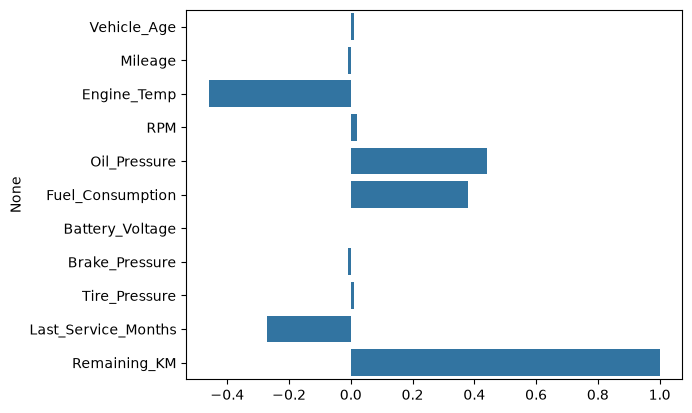

In [9]:
import seaborn  as sns
import matplotlib.pyplot as plt
corr_matriz = dados.select_dtypes(include="number").corr("spearman")["Remaining_KM"].round(2)

sns.barplot(x=corr_matriz.values, y = corr_matriz.index)


Here, `Remaining_km` seems to have a direct relationship with `oil_pressure` and `fuel_consumption`, and an inverse relationship with `engine_temp` and `last_service_months`.


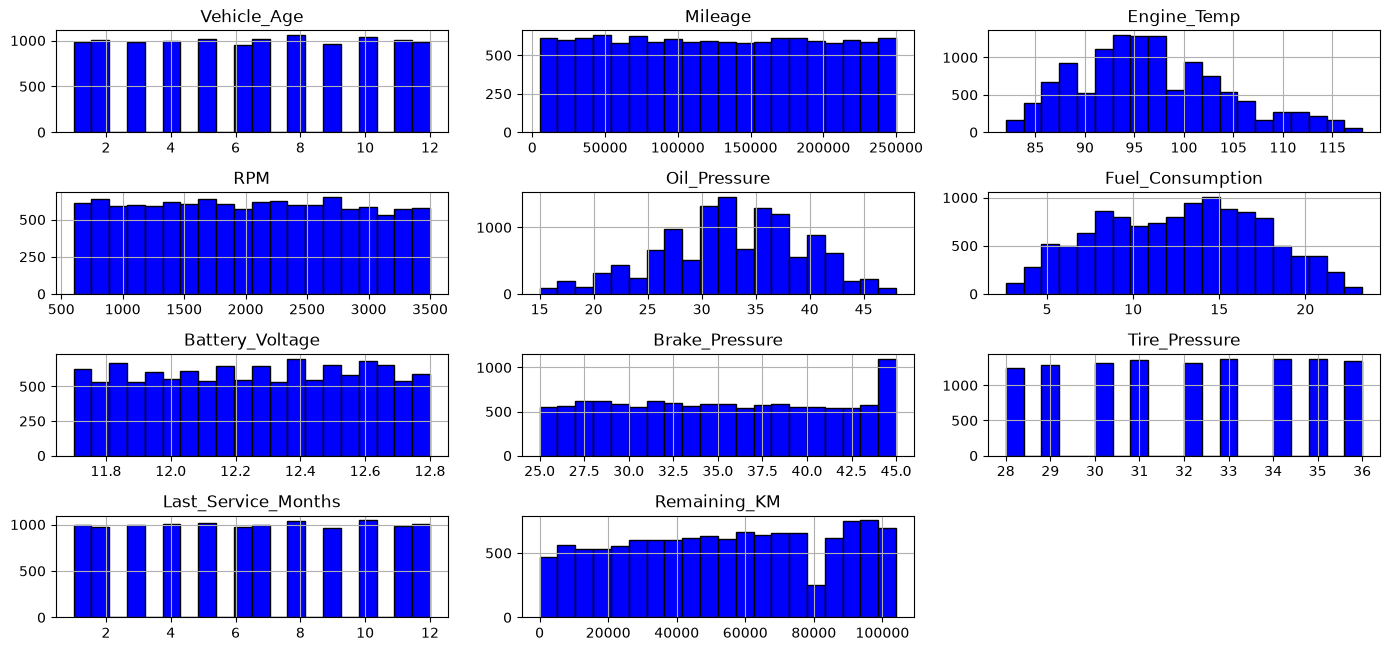

In [10]:
dados.hist(
    bins=20,
    figsize=(14, 8),
    color = "blue",
    edgecolor="black",
    layout=(5, 3)
)

plt.tight_layout()
plt.show()


NOTE 1: the remaining_km abruptly falls down between 80000. which, in turn, shows a possibly anomaly behavior. these cases could be releated with data colection or strangers behavoir among theses vehicle. 

NOTE 2: the brake pressure also shows abnormalities. suddenly the last bin increases, it can be some sensor limitation.

NOTE 3: Oil_pressure and Engine temp does not match to others features, such as RPM  and mileage. both differ from normal distribution and have unespected oscillations.

NOTE 4: the remaining features stay in a equally distribution, except fuel_consumption.


For now, we are gonna maintain the dateset the way it is for Machine Learning proposes. depend on circustainces, we are gonna clean ou do some features engineering

In [23]:
skewness = dados.skew(numeric_only=True)
skewness

Vehicle_Age           -0.008299
Mileage                0.012833
Engine_Temp            0.502013
RPM                    0.018081
Oil_Pressure          -0.262976
Fuel_Consumption      -0.019600
Battery_Voltage       -0.027568
Brake_Pressure         0.040033
Tire_Pressure         -0.031674
Last_Service_Months   -0.005598
Remaining_KM          -0.043300
dtype: float64

Text(0.5, 1.0, 'skewness')

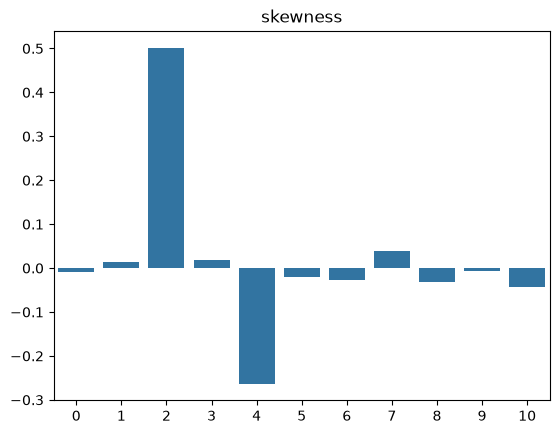

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.barplot(skewness.values)
plt.title("skewness")